In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import EchoStateNetwork, ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents

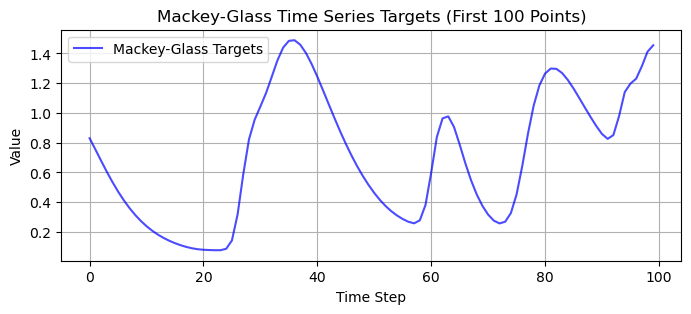

In [3]:
window_size = 20
n_samples = 20000
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples,b=0.2, c=0.5, tau = 32, window_size=window_size,prediction_horizon=30, plot=True)


In [4]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [5]:
X_test[2]

array([0.89179537, 0.73144845, 0.59923417, 0.49404113, 0.41217684,
       0.34431151, 0.28575768, 0.24671992, 0.25206207, 0.36107007,
       0.58563264, 0.82260822, 1.01878214, 1.16883515, 1.221691  ,
       1.12288782, 0.9596027 , 0.80017584, 0.66375748, 0.55292267])

In [6]:
dim=len(X_train[0])
CP_params = [-np.pi/3, 5*np.pi/6, -np.pi/8, 6*np.pi/8, np.pi/9, -np.pi/5]
cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True, ETE=False)
esn = ESNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=1, 
    show_progress=True, 
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.1,
    cpk = True
)

In [7]:
esn.fit(X_train, y_train)

Training Progress: 100%|█████████████| 15000/15000 [31:52<00:00,  7.84 sample/s]


In [8]:
predictions = esn.predict(X_test)
# print(predictions)

Prediction Progress: 100%|█████████████| 4950/4950 [08:41<00:00,  9.49 sample/s]


Quantum ESN RMSE: 0.0017


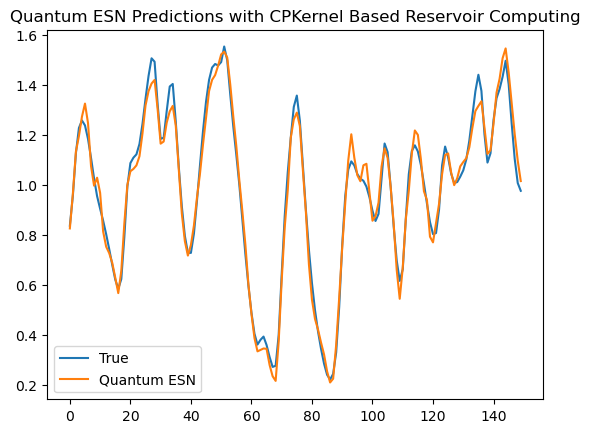

In [9]:
rmse = mean_squared_error(y_test, predictions)
print(f"Quantum ESN RMSE: {rmse:.4f}")
a = 0
b = 150
# Plot Predictions
plt.plot(y_test[a:a+b], label="True")
plt.plot(predictions[a:a+b], label="Quantum ESN")
plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
plt.legend()
plt.show()

In [7]:
a=0.001
b=1
itr=50
alpha = np.linspace(a,b,itr)

In [9]:
mses = []
for i in range(len(alpha)):
    dim=len(X_train[0])
    CP_params = [-np.pi/3, 5*np.pi/6, -np.pi/8, 6*np.pi/8, np.pi/9, -np.pi/5]
    cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True)
    esn = ESNetwork(
        reservoir=cprc, 
        dim=dim, 
        regularization=1e-6, 
        alpha=alpha[i], 
        show_progress=True, 
        approach='feedback', # 'feedback', or 'time-multiplexing'
        model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
        limit = 0.1,
        cpk = True
    )

    esn.fit(X_train, y_train)
    predictions = esn.predict(X_test)
    rmse = mean_squared_error(y_test, predictions)
    mses.append(rmse)

Prediction Progress: 100%|███████████████| 450/450 [00:43<00:00, 10.31 sample/s]


In [32]:
mses

[0.0035658048162481976,
 0.0035530705723980528,
 0.0035427932211213146,
 0.003535798566888487,
 0.0035326766084739993,
 0.003533765244132059,
 0.0035391970625489612,
 0.0035490021551783228,
 0.0035632448810189645,
 0.003582152632117932,
 0.0036061720284794444,
 0.003635873774926612,
 0.003671642492989718,
 0.0037131562380470417,
 0.003758795331713567,
 0.00380529545703439,
 0.0038480567537684143,
 0.0038823144016554333,
 0.003904764057167787,
 0.00391465464782048,
 0.003913595091526826,
 0.0039043496296023703,
 0.0038895902685681227,
 0.003871264956260147,
 0.0038505565804408093,
 0.0038281057867109317,
 0.003804258664488511,
 0.0037792591332727714,
 0.0037533819177454865,
 0.0037270152615131386,
 0.003700701139097117,
 0.0036751390615704636,
 0.0036511517028770314,
 0.0036296023461883918,
 0.0036112662188786727,
 0.0035966909920931425,
 0.003586102639968124,
 0.0035793942464770953,
 0.0035761911829867246,
 0.0035759518220950686,
 0.0035780589280422354,
 0.003581878872483161,
 0.003586

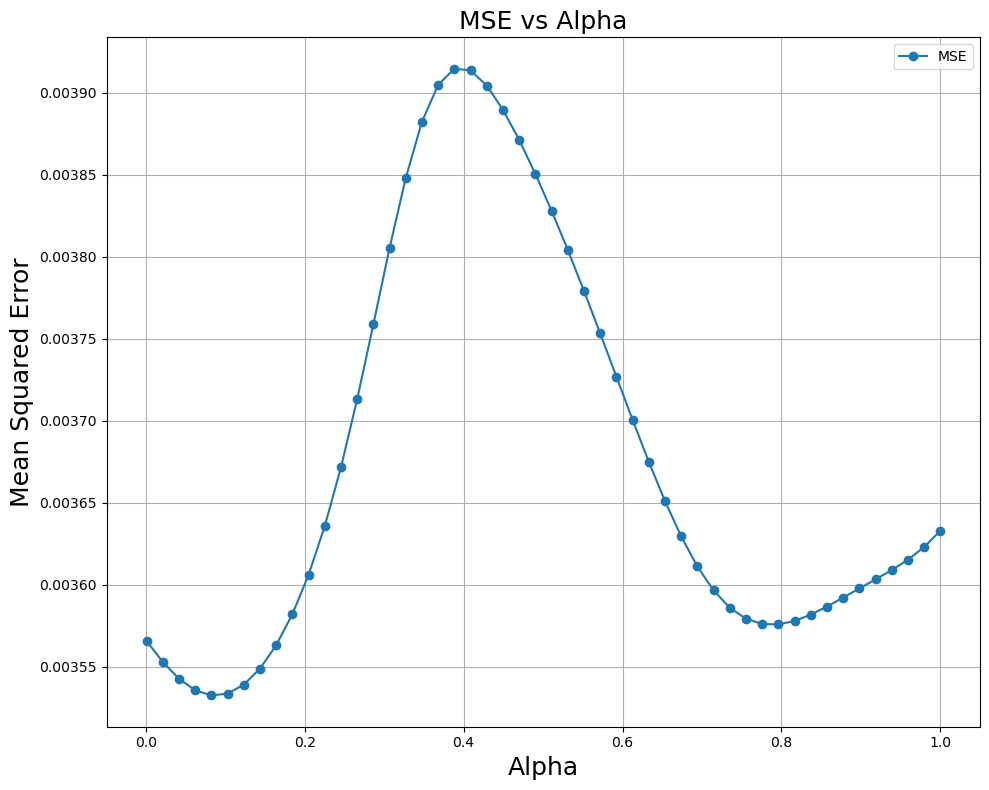

In [58]:
plt.figure(figsize=(10, 8))
plt.plot(alpha, mses, marker='o', linestyle='-', label = 'MSE')
plt.xlabel("Alpha", fontsize=18)
plt.ylabel("Mean Squared Error", fontsize=18)
plt.title("MSE vs Alpha", fontsize=18)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mse_vs_alpha_limit0.1.pdf')
plt.show()

In [10]:
n = 20 
m = 2 
initial_input = X_test[-1]  
future_predictions = esn.predict(X=None, X_test=X_test, initial_input=initial_input, n=n, m=m)
print(future_predictions)

Sequential Prediction Progress: 100%|████████| 20/20 [00:02<00:00,  9.64 step/s]

[0.81887441 0.92325945 0.88559023 0.93466755 0.99714596 1.2121424
 1.10547221 1.32053317 1.12437738 1.33655985 1.2037053  1.29801369
 1.25244859 1.16201793 1.20228742 0.96905648 1.10675303 0.8704728
 1.03529688 0.92132627]


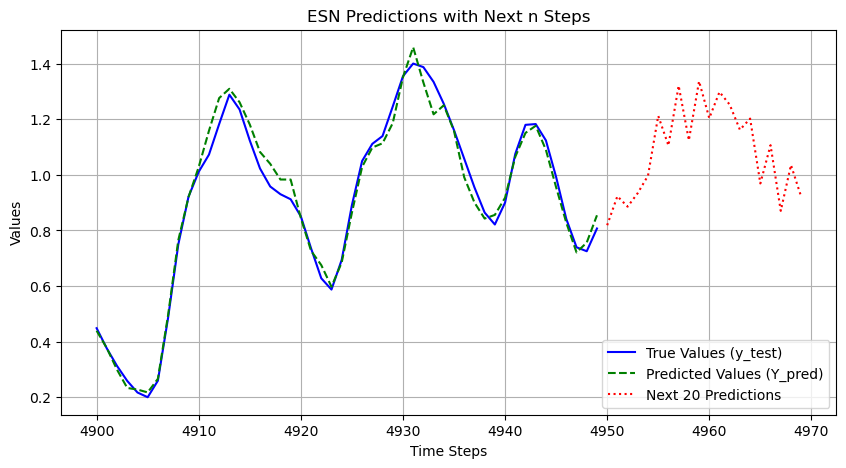

In [11]:
next_predictions = future_predictions
t_test = np.arange(len(y_test))  
t_future = np.arange(len(y_test), len(y_test) + n) 
plt.figure(figsize=(10, 5))
plt.plot(t_test[4900:], y_test[4900:], label="True Values (y_test)", color="blue", linestyle="-")
plt.plot(t_test[4900:], predictions[4900:], label="Predicted Values (Y_pred)", color="green", linestyle="--")
plt.plot(t_future, next_predictions, label=f"Next {n} Predictions", color="red", linestyle="dotted")

# Labels and legend
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.title("ESN Predictions with Next n Steps")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [51]:
# t_test = np.arange(n) 
# y_pred = future_predictions
# plt.figure(figsize=(10, 5))
# plt.plot(t_test, y_test[2:n+2], label="True Values (y_test)", color="blue", linestyle="-")
# plt.plot(t_test, y_pred, label="Predicted Values (y_pred)", color="green", linestyle="--")

# plt.xlabel("Time Steps")
# plt.ylabel("Values")
# plt.title("ESN Predictions with Next n Steps")
# plt.legend()
# plt.grid(True)
# plt.show()

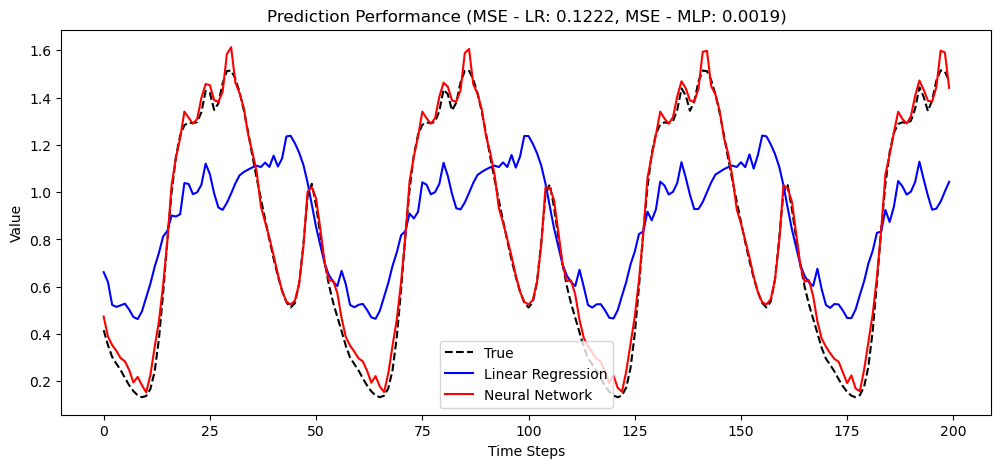

MSE for LR: 0.12223731184101654, MSE for MLP: 0.0018740199881792032


In [31]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Neural Network Regression Model
mlp_model = MLPRegressor(hidden_layer_sizes=(50,), activation='relu', max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# Evaluate Performance
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)

# Plot results0
plt.figure(figsize=(12, 5))
plt.plot(y_test[:200], label="True", linestyle="dashed", color="black")
plt.plot(y_pred_lr[:200], label="Linear Regression", color="blue")
plt.plot(y_pred_mlp[:200], label="Neural Network", color="red")
plt.legend()
plt.title(f"Prediction Performance (MSE - LR: {mse_lr:.4f}, MSE - MLP: {mse_mlp:.4f})")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.show()

# Display MSE results
print(f"MSE for LR: {mse_lr}, MSE for MLP: {mse_mlp}")

In [43]:
CRM = ClassicalRC(input_size=window_size, reservoir_size=1000, spectral_radius=0.4, sparsity=0.2,noise=0.0001,use_reservoir=True)
CRM.train(X_train, y_train, model_type="ridge")

In [44]:
y_pred = CRM.predict(X_test)
mse = CRM.evaluate(X_test, y_test)
np.sqrt(mse)

0.029067548557769236

In [45]:
# CRM.plot_predictions(y_test, y_pred, title="Reservoir Computing Prediction")

In [46]:
CRM.compute_reservoir_properties()

Reservoir Properties:
- Spectral Radius (Desired): 0.4
- Spectral Radius (Actual): 0.4000
- Sparsity (Desired): 0.2
- Sparsity (Actual): 0.8002


In [47]:
CRM.check_properties(X, Y, X_train, y_train, X_test, y_test, threshold =5e-2, plot=True)

Reservoir Property Evaluations:
- Reservoir Task RMSE: 0.0459


AttributeError: 'numpy.ndarray' object has no attribute 'apply_reservoir'

In [48]:
RegressorM = ClassicalRC(input_size=window_size, reservoir_size=1000, use_reservoir=False)
RegressorM.train(X_train, y_train, model_type="linear")

In [49]:
y_pred_reg = RegressorM.predict(X_test)
mse_reg = RegressorM.evaluate(X_test, y_test)
np.sqrt(mse_reg)

0.3496245298044983

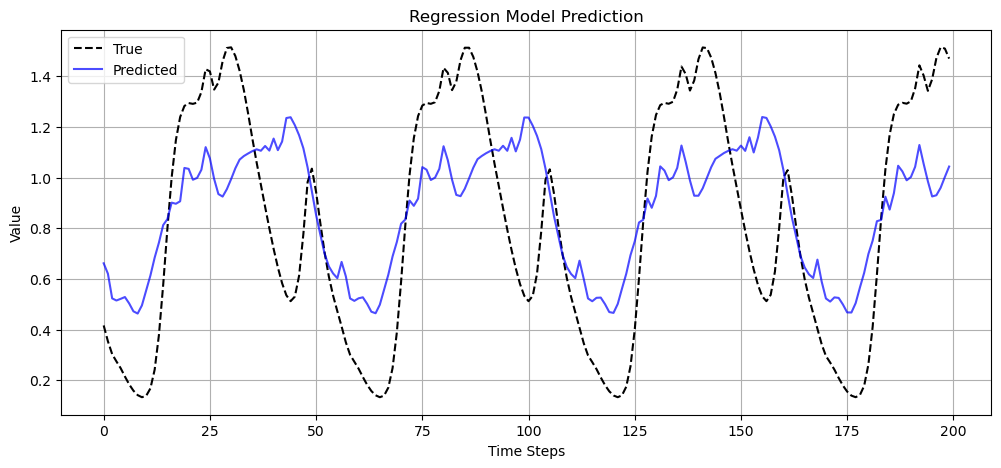

In [50]:
RegressorM.plot_predictions(y_test, y_pred_reg, title="Regression Model Prediction")

Largest Lyapunov Exponent: -0.9217778643439413


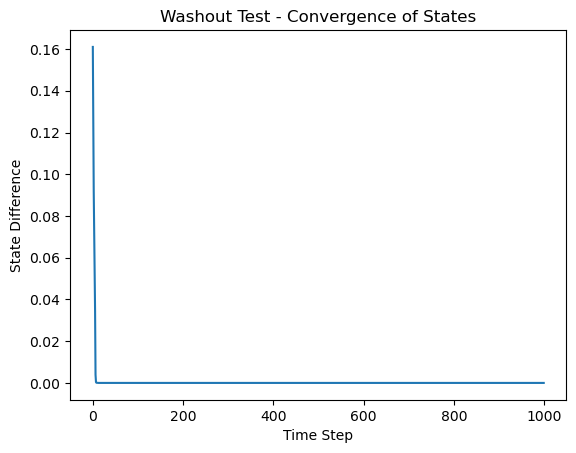

Spectral Radius: 0.8544003745317531


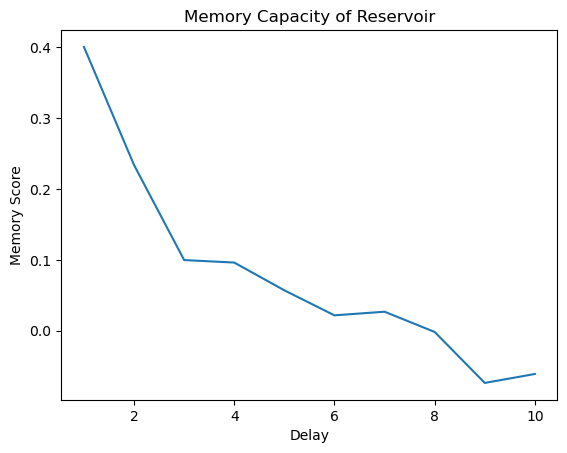

Memory Capacity Score: 0.8001785861396833


In [29]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

# 1. Largest Lyapunov Exponent (LLE)
def lyapunov_exponent(reservoir_update, x0, u_sequence, epsilon=1e-5, steps=1000):
    """
    Computes the largest Lyapunov exponent for a given reservoir.
    :param reservoir_update: Function defining reservoir state update x_{t+1} = f(x_t, u_t)
    :param x0: Initial state of the reservoir
    :param u_sequence: Input sequence applied to reservoir
    :param epsilon: Small perturbation size
    :param steps: Number of time steps to evaluate
    """
    x1 = x0.copy()
    x2 = x0 + epsilon  # Slightly perturbed initial condition
    lyapunov_sum = 0
    
    for t in range(steps):
        x1 = reservoir_update(x1, u_sequence[t])
        x2 = reservoir_update(x2, u_sequence[t])
        
        distance = np.linalg.norm(x2 - x1)
        lyapunov_sum += np.log(distance / epsilon)
        x2 = x1 + (x2 - x1) * (epsilon / distance)  # Normalize separation
    
    return lyapunov_sum / steps

# 2. Washout Test (State Convergence)
def washout_test(reservoir_update, x0, x0_prime, u_sequence, steps=1000):
    """
    Tests whether different initial conditions converge over time.
    :param reservoir_update: Reservoir update function
    :param x0: Initial state 1
    :param x0_prime: Initial state 2 (different)
    :param u_sequence: Input sequence
    :param steps: Number of steps to track
    """
    distances = []
    x1, x2 = x0.copy(), x0_prime.copy()
    
    for t in range(steps):
        x1 = reservoir_update(x1, u_sequence[t])
        x2 = reservoir_update(x2, u_sequence[t])
        distances.append(np.linalg.norm(x1 - x2))
    
    plt.plot(distances)
    plt.xlabel("Time Step")
    plt.ylabel("State Difference")
    plt.title("Washout Test - Convergence of States")
    plt.show()
    return distances

# 3. Spectral Radius Approximation (for Linear Reservoirs)
def spectral_radius(W):
    """
    Computes the spectral radius (largest eigenvalue magnitude) of a reservoir weight matrix.
    :param W: Reservoir weight matrix
    """
    eigenvalues = np.linalg.eigvals(W)
    return max(abs(eigenvalues))

# 4. Information Processing Capacity (Memory and Nonlinearity)
def compute_memory_capacity(reservoir_update, x0, input_sequence, delay=10):
    """
    Estimates how well the reservoir retains past inputs.
    :param reservoir_update: Reservoir update function
    :param x0: Initial state of the reservoir
    :param input_sequence: Input sequence
    :param delay: Number of steps to look back
    """
    memory_scores = []
    states = []
    
    x = x0.copy()
    for u in input_sequence:
        x = reservoir_update(x, u)
        states.append(x)
    states = np.array(states)
    
    for d in range(1, delay + 1):
        past_inputs = input_sequence[:-d]
        delayed_outputs = states[d:]
        corr = np.corrcoef(past_inputs, delayed_outputs[:, 0])[0, 1]  # Correlation with first state dimension
        memory_scores.append(corr)
    
    plt.plot(range(1, delay + 1), memory_scores)
    plt.xlabel("Delay")
    plt.ylabel("Memory Score")
    plt.title("Memory Capacity of Reservoir")
    plt.show()
    return sum(memory_scores)

# Example: Define a simple reservoir system
def example_reservoir_update(x, u):
    W = np.array([[0.8, 0.1], [-0.1, 0.9]])  # Example weight matrix
    return np.tanh(np.dot(W, x) + u)

# Running the tests
x0 = np.array([0.1, 0.2])
x0_prime = np.array([-0.2, 0.1])
u_sequence = np.random.randn(1000, 2)  # Random input sequence

lle = lyapunov_exponent(example_reservoir_update, x0, u_sequence)
print(f"Largest Lyapunov Exponent: {lle}")

washout_test(example_reservoir_update, x0, x0_prime, u_sequence)

sr = spectral_radius(np.array([[0.8, 0.1], [-0.1, 0.9]]))
print(f"Spectral Radius: {sr}")

mc = compute_memory_capacity(example_reservoir_update, x0, u_sequence[:, 0])
print(f"Memory Capacity Score: {mc}")
